> **SOLUTIONS notebook.** Answers are filled into the `#answer` cells below; Try the exercises yourself first.

This file is part of the CRISPRsummerschool 2026 exercises

Copyright (c) 2023-26 Christian Anthon & 2026 Gül Sude Demircan

This program is free software: you can redistribute it and/or modify
it under the terms of the GNU General Public License as published by
the Free Software Foundation, version 3.

# CRISPRon with uncertainty estimation
A model that outputs a single number ("this guide is 63% efficient") hides something important: **how sure is it?** Two guides can both be predicted at 63%, yet the model may be confident about one and essentially guessing about the other.

In this exercise we extend the simplified CRISPRon model from exercises 1-3 so that, for every guide, it reports not just a predicted efficiency but also an **uncertainty** - and we then check whether that uncertainty can be trusted.

We distinguish two kinds of uncertainty:

- **Aleatoric** uncertainty - noise inherent in the data (measurement noise, biological variability). More data does not remove it.
- **Epistemic** uncertainty - the model's own ignorance, e.g. for guides unlike anything it was trained on. More (or more diverse) training data does reduce it.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/RTH-tools/CRISPRsummerschool/blob/main/2026/CRISPR/exercise/crispr_2026_crispr_exercise4_solutions.ipynb)


## basic code definitions
Run the cell below to import the libraries, define the data-loading helpers, and download the training / validation data.

In [1]:
#!/usr/bin/env python3
# CRISPRsummerschool 2026 -- PyTorch version
import os
import copy
import numpy as np
import pandas as pd

import torch
import torch.nn as nn

# Uncomment for reproducible runs:
# torch.manual_seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

import matplotlib.pyplot as plt

eLENGTH30 = 30
eDEPTH = 4

# Function to convert DNA sequence to an index encoding (A,C,G,T/U -> 0,1,2,3)
def onehot(x):
    z = list()
    for y in list(x):
        if y in "Aa":
            z.append(0)
        elif y in "Cc":
            z.append(1)
        elif y in "Gg":
            z.append(2)
        elif y in "TtUu":
            z.append(3)
        else:
            print("Non-ATGCU character in", x)
            raise Exception
    return z

# Function to set the data into the appropriate format
def set_data(DX, s):
    if s is None:
        return
    for j, x in enumerate(onehot(s)):
        DX[j][x] = 1

# Preprocessing function for the sequence data
def preprocess_seq(data):
    DATA_X30 = np.zeros((len(data), eLENGTH30, eDEPTH), dtype=np.float32)  # onehot
    DATA_G = np.zeros((len(data), 1), dtype=np.float32)  # deltaGb
    DATA_Y = np.zeros((len(data)), dtype=np.float32)  # efficiency

    for l, d in enumerate(data):
        set_data(DATA_X30[l], d[1])
        DATA_G[l] = -d[2]
        DATA_Y[l] = d[3]
    return (DATA_X30, DATA_G, DATA_Y)

# ---- Robust data loader: identical behaviour in Colab and local Jupyter ----
# A file already in this folder is used as-is; a missing file is downloaded and
# its contents are validated. Pure Python (no shell), so it behaves the same in
# Colab, local Jupyter, Windows/Mac/Linux.
import urllib.request


DATA_SOURCES = {
    "training_data.csv": [
        "https://rth.dk/internal/index.php/s/S4jQMaER6nYAJGe/download",
    ],
    "validation_data.csv": [
        "https://rth.dk/internal/index.php/s/oHspJCgniRMog6r/download",
    ],
}


def _is_valid_csv(path):
    """A real data file starts with the known header, not an HTML error page."""
    try:
        with open(path, "r", encoding="utf-8", errors="ignore") as fh:
            first = fh.readline()
        return ("target" in first) and ("deltaGb" in first)
    except OSError:
        return False

def fetch_data(fname, dest_dir="."):
    """Return the path to a valid `fname`, downloading it only if needed.
    urllib raises on HTTP errors (unlike a bare `curl -o`) and we re-check the
    content, so a bad/expired URL fails loudly instead of silently writing an
    HTML page into a .csv."""
    dest = os.path.join(dest_dir, fname)
    if _is_valid_csv(dest):
        print("using existing", dest)
        return dest
    problems = []
    for url in DATA_SOURCES[fname]:
        try:
            print("downloading %s from %s ..." % (fname, url.split("/")[2]))
            urllib.request.urlretrieve(url, dest)
        except Exception as e:
            problems.append("%s -> %s" % (url, e))
            continue
        if _is_valid_csv(dest):
            return dest
        problems.append("%s -> downloaded file is not a valid CSV (an error page?)" % url)
    if os.path.exists(dest):
        os.remove(dest)                       # never leave a corrupt .csv behind
    raise RuntimeError(
        "Could not obtain %s. Upload it into this folder manually, or fix the "
        "URLs in DATA_SOURCES above.\nTried:\n  %s" % (fname, "\n  ".join(problems)))

fetch_data("training_data.csv")
fetch_data("validation_data.csv")


# Training / validation data
PATH = './'
d = pd.read_csv(PATH + 'training_data.csv').values.tolist()
dv = pd.read_csv(PATH + 'validation_data.csv').values.tolist()
(x30, g, y) = preprocess_seq(d)
(x30v, gv, yv) = preprocess_seq(dv)
Y_MEAN, Y_STD = float(y.mean()), float(y.std())
y  = (y  - Y_MEAN) / Y_STD
yv = (yv - Y_MEAN) / Y_STD

def to_tensors(x30, g, y):
    # one-hot stays (N, 30, 4); the model permutes to (N, 4, 30) for Conv1d
    return (torch.from_numpy(x30).to(device),
            torch.from_numpy(g).to(device),
            torch.from_numpy(y).to(device))

x30_t, g_t, y_t = to_tensors(x30, g, y)
x30v_t, gv_t, yv_t = to_tensors(x30v, gv, yv)
print('Data loaded:', x30_t.shape)


Using device: cuda
downloading training_data.csv from rth.dk ...
downloading validation_data.csv from rth.dk ...
Data loaded: torch.Size([15935, 30, 4])


## Exercise 4.1 - A model that predicts its own uncertainty
The point-prediction model from exercises 1-3 ends in a single output neuron. To make it *uncertainty-aware* we change **the output head**: instead of one number we output **two** -

- **mu**: the predicted efficiency (the mean), and
- **var**: a predicted variance (how noisy that prediction is).

A `Softplus` keeps the variance positive. Everything before the head (the convolution and the dense layers) is unchanged. This "mean-variance" head goes back to Nix & Weigend (1994).


In [2]:
class GaussianCRISPRon(nn.Module):
    """Simplified CRISPRon that predicts BOTH a mean and a variance.

    The body is identical to the point model from exercises 1-2. Only the
    output head changes: two heads produce
      * mu  : the predicted efficiency (the mean)
      * var : the predicted variance (a Softplus keeps it positive)
    """
    def __init__(self, n_conv=40, kernel=3, n_dense=40, n_out=40,
                 dropout=0.3, seq_len=30, depth=4):
        super().__init__()
        self.conv = nn.Conv1d(depth, n_conv, kernel)
        flat = n_conv * (seq_len - kernel + 1)
        self.collect = nn.Linear(flat, n_dense)
        self.dense1 = nn.Linear(n_dense + 1, n_dense)
        self.dense2 = nn.Linear(n_dense, n_out)
        self.dense3 = nn.Linear(n_out, n_out)
        self.mu_head = nn.Linear(n_out, 1)                # mean head
        self.var_head = nn.Linear(n_out, 1)               # variance head
        self.softplus = nn.Softplus()
        self.drop = nn.Dropout(dropout)
        self.apply(self._init)

    def forward(self, x, g):
        x = x.permute(0, 2, 1)                            # (B,30,4) -> (B,4,30)
        z = torch.relu(self.conv(x))
        z = torch.flatten(z, start_dim=1)
        z = self.drop(torch.relu(self.collect(z)))
        z = torch.cat([g, z], dim=1)
        z = self.drop(torch.relu(self.dense1(z)))
        z = self.drop(torch.relu(self.dense2(z)))
        z = self.drop(torch.relu(self.dense3(z)))
        mu = self.mu_head(z).squeeze(-1)                             # (B,)
        var = self.softplus(self.var_head(z)).squeeze(-1) + 1e-6     # (B,), strictly > 0
        return mu, var

    @staticmethod
    def _init(m):
        if isinstance(m, (nn.Conv1d, nn.Linear)):
            nn.init.xavier_uniform_(m.weight)
            if m.bias is not None:
                nn.init.zeros_(m.bias)

print(GaussianCRISPRon())


GaussianCRISPRon(
  (conv): Conv1d(4, 40, kernel_size=(3,), stride=(1,))
  (collect): Linear(in_features=1120, out_features=40, bias=True)
  (dense1): Linear(in_features=41, out_features=40, bias=True)
  (dense2): Linear(in_features=40, out_features=40, bias=True)
  (dense3): Linear(in_features=40, out_features=40, bias=True)
  (mu_head): Linear(in_features=40, out_features=1, bias=True)
  (var_head): Linear(in_features=40, out_features=1, bias=True)
  (softplus): Softplus(beta=1.0, threshold=20.0)
  (drop): Dropout(p=0.3, inplace=False)
)


### Training with the Gaussian negative log-likelihood
We can no longer train with mean-squared error, because MSE only cares about the mean. Instead we minimise the **Gaussian negative log-likelihood (NLL)**:

$$\mathrm{NLL} \;=\; \tfrac{1}{2}\left( \log \sigma^2 \;+\; \frac{(y-\mu)^2}{\sigma^2} \right) \;+\; \text{const}$$

Intuitively: the model is rewarded for putting the true value close to `mu`, but it is *penalised* for claiming a small variance when it turns out to be wrong. It therefore learns to output a **large** `var` for inputs it cannot predict well. PyTorch provides this as `nn.GaussianNLLLoss` - note that it takes the **variance**, not the standard deviation.


In [3]:
def train_gaussian(model, train_data, val_data, epochs=200, batch_size=64,
                   lr=1e-3, patience=25, min_delta=1e-3, verbose=True):
    """Train a mean-variance model with the Gaussian negative log-likelihood."""
    Xc, Xg, y = train_data
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    nll = nn.GaussianNLLLoss()                    # expects (mean, target, VARIANCE)
    best, best_state, wait = float("inf"), None, 0
    n = Xc.shape[0]
    for epoch in range(epochs):
        model.train()
        perm = torch.randperm(n, device=Xc.device)
        for i in range(0, n, batch_size):
            idx = perm[i:i + batch_size]
            optimizer.zero_grad()
            mu, var = model(Xc[idx], Xg[idx])
            loss = nll(mu, y[idx], var)
            loss.backward()
            optimizer.step()
        model.eval()
        with torch.no_grad():
            mu_v, var_v = model(val_data[0], val_data[1])
            val_loss = nll(mu_v, val_data[2], var_v).item()
        if val_loss < best - min_delta:
            best, best_state, wait = val_loss, copy.deepcopy(model.state_dict()), 0
        else:
            wait += 1
        if wait >= patience:
            break
    if best_state is not None:
        model.load_state_dict(best_state)
    if verbose:
        print("  best validation NLL = %.4f" % best)
    return best

def gaussian_predict(model, Xc, Xg):
    """Return (mu, var) as numpy arrays. Runs in eval mode (dropout OFF)."""
    model.eval()
    with torch.no_grad():
        mu, var = model(Xc, Xg)
    return mu.cpu().numpy(), var.cpu().numpy()

def spearman(a, b):
    # Spearman correlation = Pearson correlation on the ranks (no scipy needed)
    ra = np.argsort(np.argsort(a))
    rb = np.argsort(np.argsort(b))
    return np.corrcoef(ra, rb)[0, 1]

torch.manual_seed(0)
model_g = GaussianCRISPRon().to(device)
print("training a single Gaussian model ...")
train_gaussian(model_g, (x30_t, g_t, y_t), (x30v_t, gv_t, yv_t))

mu_v, var_v = gaussian_predict(model_g, x30v_t, gv_t)
sigma_v = np.sqrt(var_v)                          # aleatoric std (standardized units)
# Report in EFFICIENCY units (undo the target standardization) so the numbers are
# comparable to exercises 1-3:  error scales by Y_STD, variance by Y_STD**2.
print("prediction quality on validation (efficiency units):")
print("  MSE = %.3f   MAE = %.3f"
      % (np.mean((mu_v - yv) ** 2) * Y_STD ** 2, np.mean(np.abs(mu_v - yv)) * Y_STD))
print("predicted sigma:  min=%.2f  mean=%.2f  max=%.2f"
      % (sigma_v.min() * Y_STD, sigma_v.mean() * Y_STD, sigma_v.max() * Y_STD))


training a single Gaussian model ...
  best validation NLL = 0.1093
prediction quality on validation (efficiency units):
  MSE = 167.892   MAE = 10.120
predicted sigma:  min=10.95  mean=11.71  max=14.62


### Exercise 4.1 - discussion
Look at the range of predicted `sigma` values above.

- How much does `sigma` actually vary from guide to guide? How strong is the evidence that the model has   learned *input-dependent* uncertainty?
- The uncertainty produced by this single Gaussian model is **aleatoric**. Would training on more data make these `sigma` values shrink? Why or why not?


In [ ]:
# --  Sigma barely varies; the evidence that this model learned input-dependent
#   uncertainty is therefore weak: it has essentially settled on one global
#   noise level.
#   Once we train a larger version of the same architecture with less dropout, though,
#   the predicted sigma spreads about 4x , matches the actual error spread
#   closely across guides, and reaches a better validation performance- so the
#   noise really does vary.
#   Predicting the SPREAD is also intrinsically harder than predicting the mean:
#   each guide is measured once, so the model never observes any guide's noise.
#
# -- The predicted sigma is intended to represent ALEATORIC uncertainty, meaning
#   variability in the outcome conditional on the input. The true aleatoric noise
#   is irreducible: collecting more data does not make the inherent randomness of
#   an individual outcome disappear. However, the model's current estimate of
#   sigma is not necessarily correct. With more data, the mean prediction and the
#   calibration of the variance estimate may improve, so predicted sigma values
#   could shrink, increase, or remain similar. In a well-specified model, they
#   should converge toward the true conditional noise level rather than
#   necessarily shrinking toward zero.

## Exercise 4.2 - Epistemic uncertainty from a deep ensemble
A single Gaussian model captures aleatoric noise but not the model's own ignorance. A simple and surprisingly powerful way to estimate epistemic uncertainty is a deep ensemble (Lakshminarayanan et al., 2017): train several copies of the model from different random initialisations and measure how much they disagree.

For each guide we combine the members:

- mean prediction: `mu* = mean over members of mu_m`
- **aleatoric** variance: `mean over members of var_m`  (average predicted noise)
- **epistemic** variance: `variance over members of mu_m`  (how much the members disagree)
- **total** uncertainty: `total_std = sqrt(aleatoric_var + epistemic_var)`

That last line is the "uncertainties add in quadrature" rule, i.e. `total_std = sqrt(aleatoric_std**2 + epistemic_std**2)`.

Training 5 small models takes a couple of minutes.


In [5]:
M = 5   # number of ensemble members
members = []
for m in range(M):
    torch.manual_seed(100 + m)                    # a different initialisation per member
    mem = GaussianCRISPRon().to(device)
    print("training ensemble member %d/%d ..." % (m + 1, M))
    train_gaussian(mem, (x30_t, g_t, y_t), (x30v_t, gv_t, yv_t), verbose=False)
    members.append(mem)

# each member predicts a mean and a variance on the validation set
mus, varis = [], []
for mem in members:
    mu_m, var_m = gaussian_predict(mem, x30v_t, gv_t)
    mus.append(mu_m)
    varis.append(var_m)
mus = np.stack(mus)      # (M, N)
varis = np.stack(varis)  # (M, N)

mu_star       = mus.mean(axis=0)                  # ensemble mean prediction
aleatoric_var = varis.mean(axis=0)                # average predicted data noise
epistemic_var = mus.var(axis=0)                   # how much the members disagree
total_var     = aleatoric_var + epistemic_var

aleatoric_std = np.sqrt(aleatoric_var)
epistemic_std = np.sqrt(epistemic_var)
total_std     = np.sqrt(total_var)                # = sqrt(aleatoric_std**2 + epistemic_std**2)

# std / MSE / MAE printed in EFFICIENCY units (multiply by Y_STD); the standardized
# arrays above are kept as-is for the scale-free correlation & calibration plots.
print("mean aleatoric std = %.3f" % (aleatoric_std.mean() * Y_STD))
print("mean epistemic std = %.3f" % (epistemic_std.mean() * Y_STD))
print("mean total std     = %.3f" % (total_std.mean() * Y_STD))
print("ensemble  MSE = %.3f  MAE = %.3f  Spearman = %.3f"
      % (np.mean((mu_star - yv) ** 2) * Y_STD ** 2,
         np.mean(np.abs(mu_star - yv)) * Y_STD,
         spearman(mu_star, yv)))


training ensemble member 1/5 ...
training ensemble member 2/5 ...
training ensemble member 3/5 ...
training ensemble member 4/5 ...
training ensemble member 5/5 ...
mean aleatoric std = 11.962
mean epistemic std = 2.377
mean total std     = 12.239
ensemble  MSE = 162.074  MAE = 9.954  Spearman = 0.778


### Exercise 4.2 - discussion
- Which is larger on average here, the aleatoric or the epistemic std? Does that make sense given the amount of training data?
- For which guides would you expect **epistemic** uncertainty to be high? (Think about guides unlike those in the training set.)
- Which of the two uncertainties would you expect to shrink if you added more training data?


In [ ]:
# --- Exercise 4.2 (discussion) ---
print("mean aleatoric std:", round(float(aleatoric_std.mean() * Y_STD), 3))
print("mean epistemic std:", round(float(epistemic_std.mean() * Y_STD), 3))
# - Here aleatoric >> epistemic: with a fairly large dataset and a small model
#   the 5 members mostly AGREE, so the dominant uncertainty is data noise, not
#   model ignorance.
# - Epistemic uncertainty is highest for guides UNLIKE the training data (unusual
#   composition, sparsely-sampled regions of input space): there the members
#   extrapolate differently and disagree.
# - EPISTEMIC shrinks with more (or more diverse) training data -- more data
#   reduces model ignorance and makes the members converge.


mean aleatoric std: 11.962
mean epistemic std: 2.377


## Exercise 4.3 - Does the uncertainty track the error?
A useful uncertainty should be **larger when the model is more wrong**. Below we plot the absolute prediction error `|mu* - y|` against each uncertainty channel and report the Pearson and Spearman correlations.


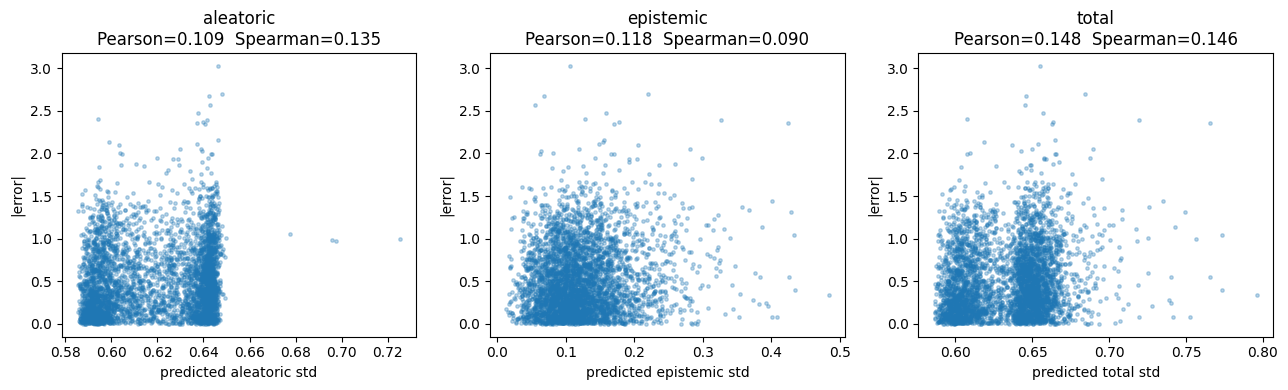

In [7]:
abs_err = np.abs(mu_star - yv)

channels = {"aleatoric": aleatoric_std, "epistemic": epistemic_std, "total": total_std}

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (name, unc) in zip(axes, channels.items()):
    ax.scatter(unc, abs_err, s=6, alpha=0.3)
    ax.set_xlabel("predicted %s std" % name)
    ax.set_ylabel("|error|")
    ax.set_title("%s\nPearson=%.3f  Spearman=%.3f"
                 % (name, np.corrcoef(unc, abs_err)[0, 1], spearman(unc, abs_err)))
plt.tight_layout()
plt.show()


### Exercise 4.3 - discussion
- Which channel (aleatoric, epistemic, or total) correlates best with the actual error?
- A perfect straight line would be ideal, but even a positive correlation is useful. What would a *flat* (zero-correlation) scatter tell you about the uncertainty estimate?


In [8]:
# --- Exercise 4.3 (discussion) ---
for name, unc in channels.items():
    print(f"{name:10s} Pearson={np.corrcoef(unc, abs_err)[0,1]:+.3f}  Spearman={spearman(unc, abs_err):+.3f}")
# - Usually TOTAL (or aleatoric, since it dominates here) correlates best with
#   the actual error: larger predicted uncertainty tends to go with larger
#   |error|. The correlation is positive but far from perfect -- uncertainty is a
#   noisy, per-example signal.
# - A FLAT (near-zero) scatter would mean the predicted uncertainty carries NO
#   information about when the model is wrong -- useless for deciding which
#   predictions to trust or which guides to prioritise.


aleatoric  Pearson=+0.109  Spearman=+0.135
epistemic  Pearson=+0.118  Spearman=+0.090
total      Pearson=+0.148  Spearman=+0.146


## Exercise 4.4 - Is the uncertainty calibrated?
Correlation only tells us whether the *ordering* of the uncertainties is right; **calibration** asks whether the *sizes* are right. If the model says "I am 90% confident the true value lies within this range", then the true value should indeed fall inside that range about 90% of the time.

For each confidence level `c` we form the two-sided interval of half-width `z * sigma`, where `z = Phi^-1((1 + c) / 2)` (e.g. `c = 0.95` gives `z = 1.96`), and count how often the true value falls inside. A perfectly calibrated model lies on the diagonal. We also report the **Expected Calibration Error (ECE)** = the mean gap to the diagonal.


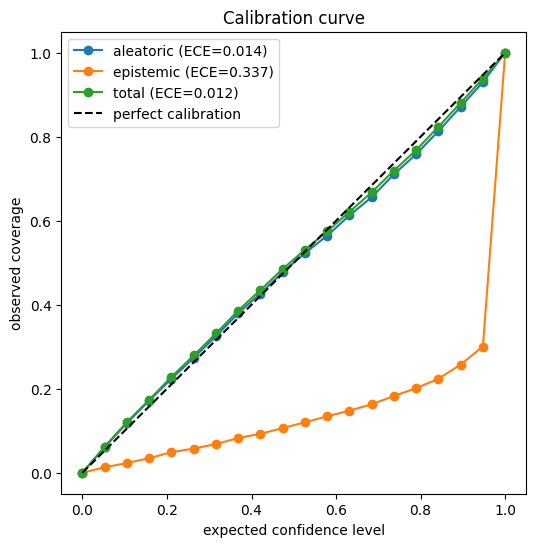

In [9]:
def calibration_curve(abs_err, sigma, n_bins=20):
    """Observed vs expected coverage. `sigma` is a STANDARD DEVIATION (not a variance).

    Reproduces the calibration logic of Stefano Roncelli's crispron package
    (crispron.metrics.calibration_z_scores / calibration_within and
    crispron.plot.CalibrationCurve): for a confidence level c the two-sided
    z-threshold is z = Phi^-1((1 + c) / 2), and we count how often the absolute
    error falls within z * sigma.
    """
    conf = torch.linspace(0, 1, n_bins)
    prob = torch.clamp((1 + conf) / 2, max=1 - 1e-8)
    z = torch.distributions.Normal(0.0, 1.0).icdf(prob)
    z[conf == 0] = 0.0                                          # zero-pin
    conf = conf.numpy()
    z = z.numpy()
    within = abs_err[None, :] <= z[:, None] * sigma[None, :]    # (n_bins, N)
    observed = within.mean(axis=1)
    ece = float(np.mean(np.abs(conf - observed)))               # expected calibration error
    return conf, observed, ece

plt.figure(figsize=(6, 6))
for name, sigma in channels.items():
    conf, observed, ece = calibration_curve(abs_err, sigma)
    plt.plot(conf, observed, "o-", label="%s (ECE=%.3f)" % (name, ece))
plt.plot([0, 1], [0, 1], "k--", label="perfect calibration")
plt.xlabel("expected confidence level")
plt.ylabel("observed coverage")
plt.title("Calibration curve")
plt.legend()
plt.show()


### Exercise 4.4 - discussion
- Is the model **over-confident** (curve *below* the diagonal - the truth escapes the interval too often) or **under-confident** (curve *above* the diagonal)?
- Does the **total** uncertainty calibrate better than aleatoric or epistemic alone?
- Why would calibration matter if you were going to use this model to *choose which guides to test in the lab*?


In [10]:
# --- Exercise 4.4 (discussion) ---
for name, sigma in channels.items():
    _, _, ece = calibration_curve(abs_err, sigma)
    print(f"{name:10s} ECE = {ece:.3f}")
# - Reading the curve: points BELOW the diagonal = OVER-confident (intervals too
#   narrow, the truth escapes more often than claimed); ABOVE = under-confident.
#   A single Gaussian head trained with NLL is often mildly over-confident.
# - TOTAL uncertainty (aleatoric + epistemic in quadrature) is usually the
#   best-calibrated channel; aleatoric alone tends to be over-confident because
#   it ignores the members' disagreement. NOTE: in THIS run epistemic << aleatoric
#   (the members mostly agree), so total = sqrt(alea^2 + epi^2) is almost equal to
#   aleatoric and their calibration curves / ECEs nearly coincide. "Total
#   calibrates best" is a general principle that becomes clearly visible only when
#   epistemic uncertainty is non-trivial (e.g. for out-of-distribution guides).
# - Why it matters for the lab: if you use the model's uncertainty to choose
#   guides (e.g. test the most uncertain ones to gain the most information, or
#   avoid them when you need reliability), those decisions are only sound if the
#   uncertainties are CALIBRATED. An over-confident model makes you trust
#   predictions you shouldn't -- wasting expensive experiments.


aleatoric  ECE = 0.014
epistemic  ECE = 0.337
total      ECE = 0.012


## References

The model these exercises build on:

- Xiang, X., Corsi, G. I., Anthon, C., *et al.* (2021). Enhancing CRISPR-Cas9 gRNA efficiency prediction by data integration and deep learning. *Nature Communications*, **12**, 3238. https://doi.org/10.1038/s41467-021-23576-0

The uncertainty methods used in this notebook:

- **Mean-variance networks** - Nix, D. A., & Weigend, A. S. (1994). Estimating the mean and variance of the target probability distribution. *Proceedings of 1994 IEEE International Conference on Neural Networks (ICNN'94)*, **1**, 55-60. https://doi.org/10.1109/ICNN.1994.374138
- **Deep ensembles** - Lakshminarayanan, B., Pritzel, A., & Blundell, C. (2017). Simple and scalable predictive uncertainty estimation using deep ensembles. *Advances in Neural Information Processing Systems (NeurIPS)*, **30**, 6402-6413. https://arxiv.org/abs/1612.01474
- **Calibration of regression uncertainty** - Kuleshov, V., Fenner, N., & Ermon, S. (2018). Accurate uncertainties for deep learning using calibrated regression. *Proceedings of the 35th International Conference on Machine Learning (ICML)*, PMLR **80**, 2801-2809. https://arxiv.org/abs/1807.00263
